In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, cauchy

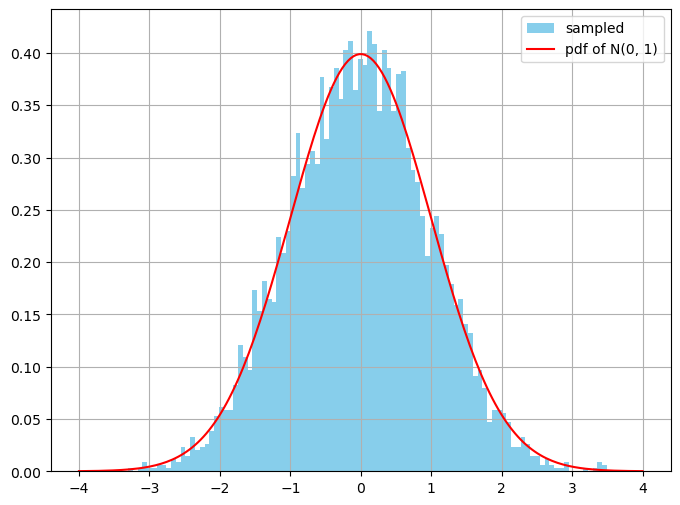

In [2]:
np.random.seed(42)

f = lambda x: norm.pdf(x)
g = lambda x: cauchy.pdf(x)

C = 1.5

def rejection_sampling(n):
    accepted = []
    while len(accepted) < n:
        x = cauchy.rvs()
        u = np.random.uniform(0, 1)
        if u <= f(x) / (C * g(x)):
            accepted.append(x)
    return np.array(accepted)

x_=np.linspace(-4, 4, 200)
samples=rejection_sampling(5000)

plt.figure(figsize=(8, 6))
plt.hist(x=samples, bins=100, density=True, label='sampled', color='skyblue')
plt.plot(x_, norm.pdf(x_), label='pdf of N(0, 1)', color='r')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
Y = np.sin(samples)
estimated_expectation = np.mean(Y)
standard_error = np.std(Y) / np.sqrt(len(Y))
print(f'Estimated E[sin(X)] = {estimated_expectation:.4f}')
print(f'Standard Error = {standard_error:.4f}')

Estimated E[sin(X)] = -0.0058
Standard Error = 0.0093


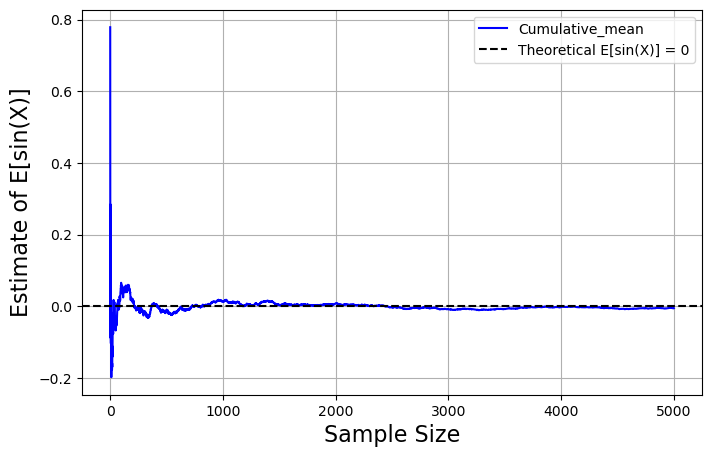

In [4]:
cumulative_mean = np.cumsum(Y) / np.arange(1, len(Y)+1)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_mean, label='Cumulative_mean', color='b')
plt.axhline(0, color='k', linestyle='--', label='Theoretical E[sin(X)] = 0')
plt.xlabel("Sample Size", fontsize=16)
plt.ylabel("Estimate of E[sin(X)]", fontsize=16)
plt.legend()
plt.grid(True)
plt.show()


In [5]:
import numpy as np
np.random.seed(42)
n = 5000
x = []
y = []
while len(x) < n:
    x_test = np.random.uniform(-1, 1, size=1000)
    y_test = np.random.uniform(-1, 1, size=1000)
    mask = (x_test**2 + y_test**2) < 1
    x.extend(x_test[mask])
    y.extend(y_test[mask])
x = np.array(x[:n])
y = np.array(y[:n])
f_values = (x**2)*np.cos(x**4+y**2)
integral_estimate = np.pi*np.mean(f_values)
std_error = (np.pi*np.std(f_values))/np.sqrt(n)
print(f"Estimated integral: {integral_estimate:.4f}")
print(f"Standard error: {std_error:.4f}")

Estimated integral: 0.6764
Standard error: 0.0090


In [ ]:
import numpy as np
np.random.seed(42)
n_r = 500
n_theta = 500
r_range = np.linspace(0, 1, n_r)
theta_range = np.linspace(0, 2 * np.pi, n_theta)
r, theta = np.meshgrid(r_range, theta_range, indexing='ij')
x = r * np.cos(theta)
y = r * np.sin(theta)
f = (r**2) * (np.cos(theta))**2 * np.cos((r**4)*(np.cos(theta)**4) + (r**2)*(np.sin(theta)**2))
dr = r_range[1] - r_range[0]
dtheta = theta_range[1] - theta_range[0]
integral_estimate = np.sum(f * r) * dr * dtheta
print(f'Estimated integral: {integral_estimate:.4f}')

Estimated integral  0.6810


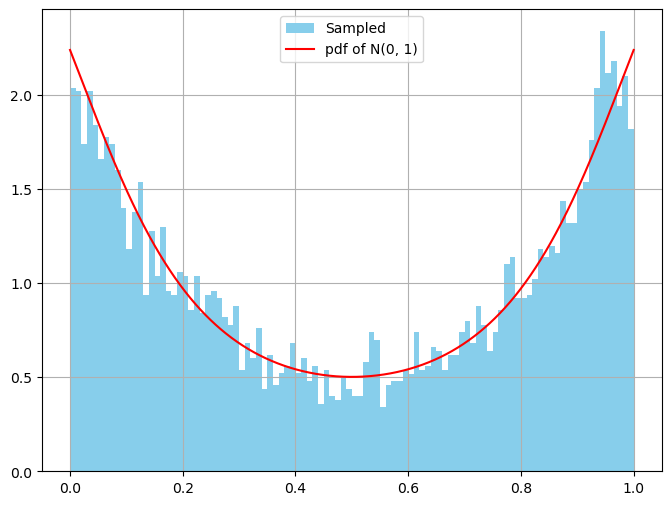

In [7]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
def f(z):
    return (1+(np.cos((z-0.5)/0.4))**2)**(-2.5)
z_range = np.linspace(0, 1, 1000)
f_value = f(z_range)
C = np.max(f_value)
n = 5000
accepted = []
while len(accepted) < n:
    z = np.random.uniform(0, 1)
    u = np.random.uniform(0, 1)
    if u <= f(z) / C:
        accepted.append(z)
samples=np.array(accepted)
plt.figure(figsize=(8, 6))
plt.hist(x=samples, bins=100, density=True, label='Sampled', color='skyblue')
plt.plot(z_range, f_value/np.trapz(f_value, z_range), label='pdf of N(0, 1)', color='r')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import numpy as np
threshold = 0.3
n = len(samples)
I1 = np.sum(samples < threshold) / n
print(f"Estimated P(Z < 0.3), i.e. I1: {I1:.4f}")

Estimated P(Z < 0.3), i.e. I1: 0.3854


In [9]:
import numpy as np
np.random.seed(42)
def f(z):
    return (1+(np.cos((z-0.5)/0.4))**2)**(-2.5)
n = 5000
z_range = np.linspace(0, 1, n)
z_part = z_range[z_range <= 0.3]
f_range = f(z_range)
f_part = f(z_part)
dz = z_range[1] - z_range[0]
area_total = np.sum(f_range)*dz
area_less_than_03 = np.sum(f_part)*dz
I2 = area_less_than_03/area_total
print(f"Estimated P(Z < 0.3), i.e. I2: {I2:.4f}")

Estimated P(Z < 0.3), i.e. I2: 0.3883


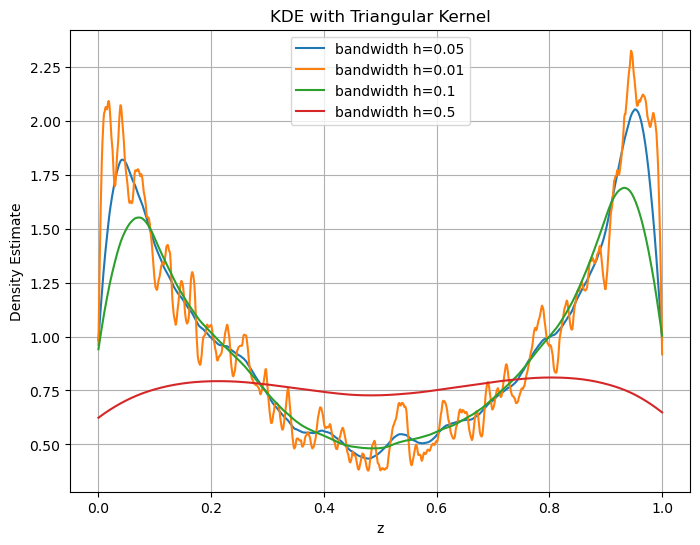

In [10]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
def tri_ker(x):
    return np.where(np.abs(x)<=1, 1-np.abs(x), 0)
def kde_tri_ker(z_range, samples, bandwidth):
    n = len(samples)
    kde_value = np.zeros_like(z_range)
    for i, z in enumerate(z_range):
        x = (z-samples)/bandwidth
        kde_value[i] = np.sum(tri_ker(x))
    return kde_value/(n*bandwidth)
z_range = np.linspace(0, 1, 1000)
bandwidth_list = [0.05, 0.01, 0.1, 0.5]
plt.figure(figsize=(8, 6))
for i in bandwidth_list:
    kde = kde_tri_ker(z_range, samples, i)
    plt.plot(z_range, kde, label=f'bandwidth h={i}')
plt.title('KDE with Triangular Kernel')
plt.xlabel("z")
plt.ylabel("Density Estimate")
plt.legend()
plt.grid(True)
plt.show()

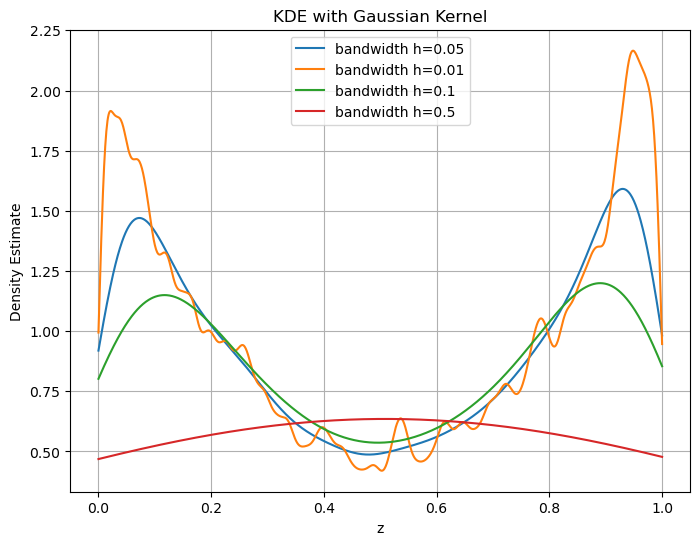

In [11]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
def gaus_ker(x):
    return (1/np.sqrt(2*np.pi))*np.exp(-0.5*(x**2))
def kde_gaus_ker(z_range, samples, bandwidth):
    n = len(samples)
    kde_value = np.zeros_like(z_range)
    for i, z in enumerate(z_range):
        x = (z-samples)/bandwidth
        kde_value[i] = np.sum(gaus_ker(x))
    return kde_value/(n*bandwidth)
z_range = np.linspace(0, 1, 1000)
bandwidth_list = [0.05, 0.01, 0.1, 0.5]
plt.figure(figsize=(8, 6))
for i in bandwidth_list:
    kde = kde_gaus_ker(z_range, samples, i)
    plt.plot(z_range, kde, label=f'bandwidth h={i}')
plt.title('KDE with Gaussian Kernel')
plt.xlabel("z")
plt.ylabel("Density Estimate")
plt.legend()
plt.grid(True)
plt.show()

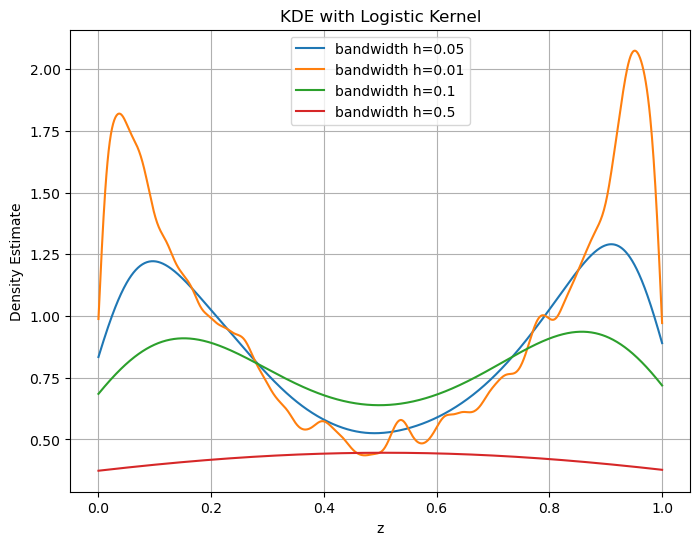

In [12]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
def log_ker(x):
    return 1/(np.exp(x)+2+np.exp(-x))
def kde_log_ker(z_range, samples, bandwidth):
    n = len(samples)
    kde_value = np.zeros_like(z_range)
    for i, z in enumerate(z_range):
        x = (z-samples)/bandwidth
        kde_value[i] = np.sum(log_ker(x))
    return kde_value/(n*bandwidth)
z_range = np.linspace(0, 1, 1000)
bandwidth_list = [0.05, 0.01, 0.1, 0.5]
plt.figure(figsize=(8, 6))
for i in bandwidth_list:
    kde = kde_log_ker(z_range, samples, i)
    plt.plot(z_range, kde, label=f'bandwidth h={i}')
plt.title('KDE with Logistic Kernel')
plt.xlabel("z")
plt.ylabel("Density Estimate")
plt.legend()
plt.grid(True)
plt.show()